# ***Importing libraries and The data***

In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary

import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

import glob
import os


In [308]:
device = "cuda" if torch.cuda.is_available() else "cpu" 
print("Device available: ", device)

Device available:  cuda


In [309]:
First_degree = os.path.join("..", "data", "1st degree")
Second_degree = os.path.join("..", "data", "2nd degree")
Third_degree = os.path.join("..", "data", "3rd degree")

In [310]:
first_degree_images = glob.glob(os.path.join(First_degree, "*"))
second_degree_images = glob.glob(os.path.join(Second_degree, "*"))
third_degree_images = glob.glob(os.path.join(Third_degree, "*"))
print(f"Number of first degree burn images: {len(first_degree_images)}")
print(f"Number of second degree burn images: {len(second_degree_images)}")
print(f"Number of third degree burn images: {len(third_degree_images)}")

Number of first degree burn images: 543
Number of second degree burn images: 488
Number of third degree burn images: 326


In [311]:
all_images = first_degree_images + second_degree_images + third_degree_images
labels = [0] * len(first_degree_images) + [1] * len(second_degree_images) + [2] * len(third_degree_images)
data = pd.DataFrame({"image_path": all_images, "label": labels})

print(f"Total number of images: {len(data)}")
print(data.head())

Total number of images: 1357
                                          image_path  label
0  ..\data\1st degree\gettyimages-114329113-612x6...      0
1  ..\data\1st degree\gettyimages-1263088074-612x...      0
2  ..\data\1st degree\gettyimages-1411774798-612x...      0
3  ..\data\1st degree\gettyimages-1413010078-612x...      0
4  ..\data\1st degree\gettyimages-155427805-612x6...      0


# ***Data Splitting***

In [312]:
# Split the data into training, validation and testing sets

train_data, temp_data = train_test_split(data, test_size=0.3, stratify=data["label"], random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, stratify=temp_data["label"], random_state=42)

# ***Augmentation***

In [313]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [314]:
class BurnDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["image_path"]
        label = self.dataframe.iloc[idx]["label"]
        
        from PIL import Image
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [315]:
# Create datasets
train_dataset = BurnDataset(train_data, transform=train_transforms)
val_dataset = BurnDataset(val_data, transform=val_transforms)
test_dataset = BurnDataset(test_data, transform=val_transforms)

In [316]:
# Create data loaders
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [317]:
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 60
Val batches: 13
Test batches: 13


In [318]:
dataset = ImageFolder(root=os.path.join("..", "data"), transform=val_transforms)
def show_img(img, label):
    print("Label:", dataset.classes[label], "(Class No: "+ str(label) + ")")
    plt.imshow(img.permute(1, 2, 0))

Label: 1st degree (Class No: 0)


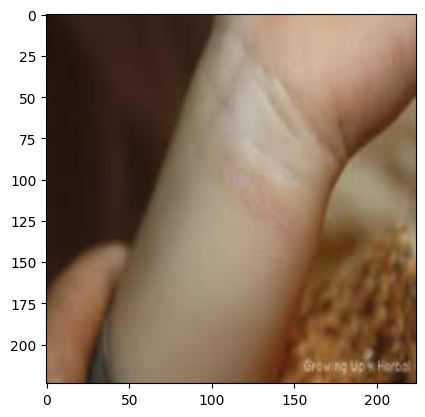

In [319]:
from PIL import Image
row = val_dataset.dataframe.iloc[1]
img = Image.open(row.image_path).convert("RGB")
img_tensor = val_transforms(img)
show_img(img_tensor, row.label)

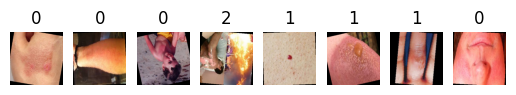

In [320]:
import matplotlib.pyplot as plt

def show_batch(dl, n=8):
    imgs, labs = next(iter(dl))
    for i in range(n):
        img = imgs[i].permute(1,2,0).cpu().numpy()
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.title(labs[i].item())
        plt.axis('off')

show_batch(train_loader)